# Assignment 4: Regularization 

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?
2. How does regularization provide a way of exploring the bias-variance trade-off?
3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?
4. How do we typically scale variables for use in regularized regression? Why?
5. How is the penalty $\alpha$ typically selected?
6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

1. The intuition of adding a penalty to the MSE is to control the complexity of the model and reduce model variance as regularization forces the model to pick more predictive variables and reduce coefficient size. Essentially, complex models are penalized, with there being two forms of penalties: LASSO (absolute value penalty) and Ridge (squared penalty).
2. Regularization provides a way for exploring bias-variance trade-off by reducing model variance in a way that is principled and data-driven. By changing "a", the strength of the penalty, we're changing how much complexity we're willing to trade for bias. As a model becomes simpler, it may become more biased. Specifically, we explore this concept by picking the "a" term using cross validation in order to find the best penalty and most optimal model complexity.
3. LASSO regression shrinks other variables as "a" increases, until all coefficients are zero. As a result, coefficients that reduce to zero are dropped, and models are chosen for us. On the other hand, Ridge shrinks coefficients towards zero; they aren't ever dropped completely. This is because the LASSO penalty has points of non-differentiability at zero, while the Ridge penalty is smooth at zero. Ridge typically performs better since it doesn't remove any coefficients, addressing the prediction problem. LASSO provides more interpretable answers since there's only a few variables to observe, addressing the interpretation problem.
4. Variables need to be standardized in order to use regularized regression, so they exist on the same scale. If they aren't scaled, the model may generate inaccurate results if several different units of measure are involved. For example, comparing two variables like age and income, the model might force the age variable to zero simply because its units are smaller. This is problematic if it's a valid predictor. Standardization also allows for easier interpretation across variables of different features.
5. The penalty "a" is typically selected using cross-validation. The procedure follows: pick a grid, or range, of "a" values to use, use k-fCV on each "a" value to train and test the model, calculate the mean/median MSE of all k test folds, and select the best "a" that produced the lowest average MSE.
6. No, you don't include the penalty term in evaluating the cross validated MSE. This is because the penalty term is only used to control the complexity of the model and reduce model variance. Therefore, the penalty isn't predictive of a model's MSE. Additionally, penalty values aren't predictive or correlated to a model's accuracy. The predictions of a model may be accurate even if the penalty value is significant.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them. 
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [111]:
import numpy as np
import pandas as pd

df = pd.read_csv('./data/cars_hw.csv', encoding='latin1')
df.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


In [112]:
#1
df['Age'] = 2026 - df['Make_Year']
df.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price,Age
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000,9
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000,10
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000,7
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000,9
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000,9


In [113]:
#1 continued
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

X = df[['Mileage_Run', 'Age']]

poly = PolynomialFeatures(degree=3 ,include_bias=False)
X_poly = poly.fit_transform(X) 

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

In [114]:
#2
from sklearn.linear_model import LinearRegression

y = df['Price']
model = LinearRegression()
model.fit(X_scaled, y)

feature_names = poly.get_feature_names_out(['Mileage_Run', 'Age'])
coeffs = pd.Series(model.coef_, index=feature_names)

interaction_coef = coeffs['Mileage_Run Age']
sign = "positive" if interaction_coef > 0 else "negative"

print(f'Interaction Coefficient: {interaction_coef}')
print(f'Interaction Sign: {sign}')

Interaction Coefficient: -1671212.3563918832
Interaction Sign: negative


In [115]:
#3
from sklearn.linear_model import LassoCV

alphas = np.logspace(1,3,20)
model = LassoCV(cv = 20,
                alphas = alphas,
                random_state = 100)
model = model.fit(X_scaled, y)

print('Best alpha:', model.alpha_)

Best alpha: 69.51927961775606


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.385e+10, tolerance: 1.268e+10
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.463e+11, tolerance: 1.268e+10
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the numb

/var/folders/5c/q3x36f2x0p79tf2yc7m0jjg00000gn/T/ipykernel_49487/1020645043.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


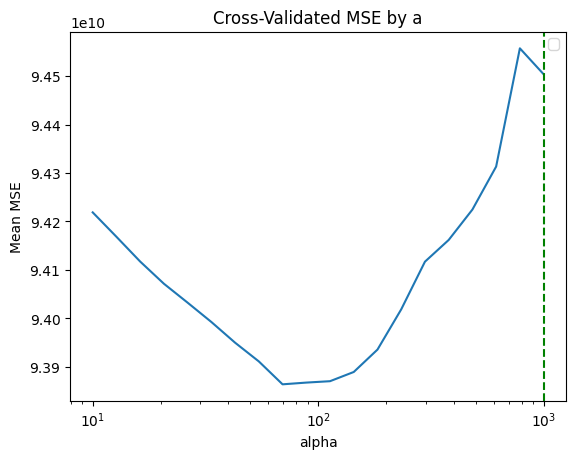

In [116]:
#4
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV, lasso_path

index_star = np.argmin(np.median(model.mse_path_, axis=1))
alpha_star = model.alphas_[index_star]

sns.lineplot(x = model.alphas_, y=np.mean(model.mse_path_, axis=1))
plt.axvline(x = alpha_star, color = 'green', linestyle ='--', linewidth = 1.5)
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Mean MSE')
plt.title('Cross-Validated MSE by a')
plt.legend()
plt.show()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.405e+10, tolerance: 1.316e+10
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.677e+10, tolerance: 1.316e+10
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iter

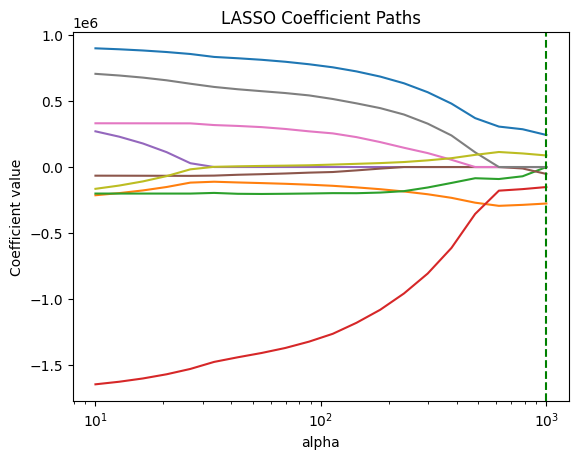

In [117]:
#5
from sklearn.linear_model import Lasso

coefs = []
for alpha in alphas:
    model = Lasso(alpha=alpha, max_iter=10_000)
    model = model.fit(X_scaled, y)
    coefs.append(model.coef_)
coefs = np.array(coefs)

plt.figure()
for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i], label=feature_names[i])
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Coefficient value')
plt.title('LASSO Coefficient Paths')
plt.axvline(x=alpha_star, color='green', linestyle='--')
plt.show()

In [118]:
#6
feature_names = poly.get_feature_names_out(['Mileage_Run', 'Age'])
selected_features = feature_names[model.coef_ !=0]

print(selected_features)

['Mileage_Run' 'Age' 'Mileage_Run Age' 'Mileage_Run^3' 'Age^3']


In [119]:
#6 (proportion)
dropped_features = feature_names[model.coef_ == 0]
total = len(feature_names)
dropped_total = len(dropped_features)
proportion = dropped_total / total

print(proportion)

0.4444444444444444


Question 6: Features "Mileage_Run", "Age", "Mileage_Run Age", "Mileage_Run^3", and "Age^3" were selected. These features didn't equal to zero and have actual (positive or negative) values. The proportion I found is 0.444.

In [120]:
#7
comparison = pd.DataFrame({'Linear_Reg': coeffs, 'LASSO': model.coef_}, index=feature_names)
print(comparison[comparison['LASSO'] != 0])

                   Linear_Reg          LASSO
Mileage_Run      9.117748e+05  242953.216388
Age             -2.481722e+05 -276500.895776
Mileage_Run Age -1.671212e+06 -151598.545767
Mileage_Run^3   -6.514490e+04  -52410.347536
Age^3           -2.100379e+05   87796.740706


Question 7: Age increased in magnitude from Linear Regression to LASSO, while Age^3 changed from a negative sign in Linear Regression to positive in LASSO.

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

In [121]:
#1
df = pd.read_csv('./data/heart_failure_clinical_records_dataset.csv', encoding='latin1')
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [122]:
#1 continued
X = df[['age', 'ejection_fraction', 'serum_creatinine']]
poly = PolynomialFeatures(degree=3 ,include_bias=False)
X_poly = poly.fit_transform(X) 

X_dummy = df[['anaemia', 'diabetes', 'high_blood_pressure', 'smoking']]
poly_dummy = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_poly_dummy = poly_dummy.fit_transform(X_dummy)

X_results = np.hstack([X_poly, X_poly_dummy])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_results)

names_X = poly.get_feature_names_out()
names_dummy = poly_dummy.get_feature_names_out()
all_feature_names = np.concatenate([names_X, names_dummy])

In [123]:
#2
y = df['DEATH_EVENT']
model = LinearRegression()
model.fit(X_scaled, y)

coeffs = pd.Series(model.coef_, index=all_feature_names)
print(f'All Coefficients: {coeffs}')

All Coefficients: age                                       1.539156
ejection_fraction                        -2.192494
serum_creatinine                         -0.853588
age^2                                    -3.678654
age ejection_fraction                    -0.600918
age serum_creatinine                      1.841563
ejection_fraction^2                       3.430976
ejection_fraction serum_creatinine        2.673394
serum_creatinine^2                       -2.647041
age^3                                     1.993135
age^2 ejection_fraction                   0.908026
age^2 serum_creatinine                   -0.697522
age ejection_fraction^2                  -0.081206
age ejection_fraction serum_creatinine   -1.577665
age serum_creatinine^2                    1.284099
ejection_fraction^3                      -1.250341
ejection_fraction^2 serum_creatinine     -1.270043
ejection_fraction serum_creatinine^2      1.179475
serum_creatinine^3                        0.072156
anaemia      

In [124]:
#2 (looking at smoking and diabetes specifically)
for feature in ['smoking', 'diabetes']:
    interaction_coef = coeffs[feature]
    sign = "positive" if interaction_coef > 0 else "negative"
    print(f'{feature} coefficient: {interaction_coef} ({sign})')

smoking coefficient: -0.047943108233764554 (negative)
diabetes coefficient: -0.03487459391904329 (negative)


Question 2: After running linear regression, I noticed that the features "smoking" and "diabetes" had negative coefficients. I found this interesting because both smoking and diabetes are factors for increased heart failure. This seems counterintuitive as they should have positive coefficients since these features normally raise the probability of a death event. The model is implying that these features, which are normally risk factors, actually decrease the probability of death. Therefore, the inclusion of higher-order powers or interactions could potentially resolve this contradiction by uncovering relationships that the model may have missed. For example, I can see how "diabetes high_blood_pressure" and "diabetes smoking" have positive coefficients, while diabetes on its own has a negative coefficient. Additionally, we can further investigate these features' relationships with the age feature, which might give us more helpful and conclusive results.

In [125]:
#3
alphas = np.logspace(-5,5,30)
model_cv = LassoCV(cv = 20,
                alphas = alphas,
                random_state = 100)
model_cv = model_cv.fit(X_scaled, y)

print('Best alpha:', model_cv.alpha_)

Best alpha: 0.005736152510448681


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.016e-01, tolerance: 5.832e-03
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.807e-01, tolerance: 5.832e-03
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the numb

/var/folders/5c/q3x36f2x0p79tf2yc7m0jjg00000gn/T/ipykernel_49487/732108441.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


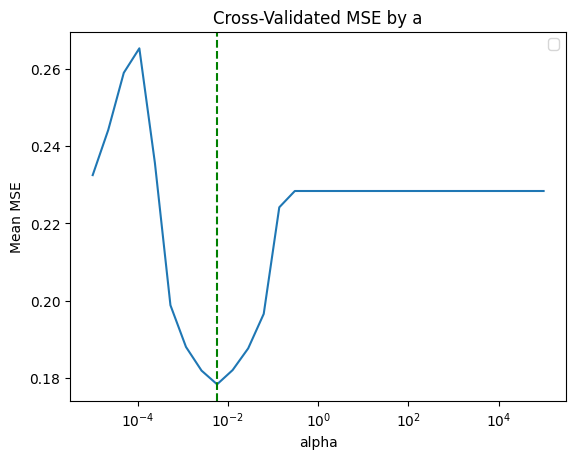

In [126]:
#4
index_star = np.argmin(np.mean(model_cv.mse_path_, axis=1))
alpha_star = model_cv.alphas_[index_star]

sns.lineplot(x = model_cv.alphas_, y=np.mean(model_cv.mse_path_, axis=1))
plt.axvline(x = alpha_star, color = 'green', linestyle ='--', linewidth = 1.5)
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Mean MSE')
plt.title('Cross-Validated MSE by a')
plt.legend()
plt.show()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.908e+01, tolerance: 6.518e-03
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.666e+01, tolerance: 6.518e-03
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iter

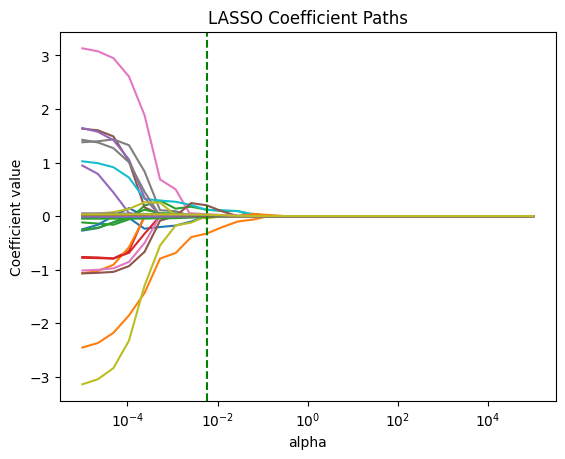

In [127]:
#5
coefs = []
for alpha in alphas:
    model = Lasso(alpha=alpha, max_iter=10_000)
    model = model.fit(X_scaled, y)
    coefs.append(model.coef_)
coefs = np.array(coefs)

plt.figure()
for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i], label=all_feature_names[i])
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('Coefficient value')
plt.title('LASSO Coefficient Paths')
plt.axvline(x=alpha_star, color='green', linestyle='--')
plt.show()

In [128]:
#6
selected_features = all_feature_names[model_cv.coef_ !=0]
print(selected_features)

# proportion
dropped_features = all_feature_names[model_cv.coef_ == 0]
total = len(all_feature_names)
dropped_total = len(dropped_features)
proportion = dropped_total / total
print(proportion)

# comparison
comparison = pd.DataFrame({'Linear_Reg': coeffs, 'LASSO': model_cv.coef_}, index=all_feature_names)
print(comparison[comparison['LASSO'] != 0])

['ejection_fraction' 'serum_creatinine' 'age^3' 'ejection_fraction^3'
 'ejection_fraction^2 serum_creatinine' 'serum_creatinine^3' 'anaemia'
 'smoking' 'anaemia diabetes' 'diabetes high_blood_pressure'
 'diabetes smoking' 'high_blood_pressure smoking']
0.5862068965517241
                                      Linear_Reg     LASSO
ejection_fraction                      -2.192494 -0.326124
serum_creatinine                       -0.853588  0.117426
age^3                                   1.993135  0.116214
ejection_fraction^3                    -1.250341  0.200750
ejection_fraction^2 serum_creatinine   -1.270043  0.034419
serum_creatinine^3                      0.072156 -0.045558
anaemia                                 0.004008  0.013163
smoking                                -0.047943 -0.019828
anaemia diabetes                        0.009990  0.000310
diabetes high_blood_pressure            0.046474  0.024535
diabetes smoking                        0.046893  0.017410
high_blood_pressure 

Question 6: 
The selected features are the ones listed above, ranging from "ejection_fraction" to "high_blood_pressure smoking." The proportion of features that are set equal to zero is 0.586. Anaemia increased in magnitude from linear regression to LASSO, while all others decreased. Serum_creatinine, ejection_fraction^3, ejection_fraction^2 serum_creatinine, and serum_creatinine^3 changed signs. 

The sign patterns for the LASSO seem to make more sense. Earlier, the smoking coefficient in linear regression was -0.0479. On the other hand, it shrank to -0.0198 in LASSO. This coefficient is more reasonable from a health standpoint. LASSO also displayed positive interaction coefficients for important features like "diabetes smoking" and "high_blood_pressure smoking." The LASSO model illustrates how smoking data on its own might be deceiving when relationships between other features aren't uncovered. 

Discussing the bias-variance tradeoff, we see that the results from LASSO were more logical since it's a regularized model. Regularization provides a solution to reduce model variance. This is something that the linear regression model lacked.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

![HW Solutions](IMG_6671.JPG)

Questions 1 & 2: answers in picture above

Question 3: Looking at what I solved for in question 2, I found that b1 has a in its denominator. If a increased, then the denominator would get larger. This operation would cause b1, or the slope coefficient, to get smaller and shrink to zero. As a result, the slope will be less steep.

Question 4: The challenge faced when we use the LASSO penalty instead is that it's not differentiable at b1=0. The absolute value creates a sharp "corner" where you're unable to take the derivative at that point. There are some different solutions to different scenarios of this challenge. If the coefficient is too big, the model will shrink it to towards 0 based off the penalty amount. If the coefficient is less than the penalty, the model will force it to be exactly zero. It's optimal to set b1=0 when the magnitude of the correlation between the variable and target features aren't bigger than the a penalty. The LASSO penalty works so that once coefficients  hit zero, they can be dropped from the model. LASSO selects a specific model for us in this way.